In [1]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, load_from_disk
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from dotenv import load_dotenv
from mpl_toolkits.axes_grid1 import ImageGrid
load_dotenv()

True

In [2]:
# Load the zero-shot VSR dataset into a DataFrame
ds = load_dataset("cambridgeltl/vsr_zeroshot")
df = ds["train"].to_pandas()

In [3]:
def plot_stacked_bar(df, group_col, label_col='label', title='', figsize=(18,4)):
    """
    Plot a stacked bar chart grouping by `group_col` and splitting by `label_col`.
    """
    data = (
        df[[group_col, label_col]]
        .groupby([group_col, label_col])
        .size()
        .unstack(fill_value=0)
    )
    data['total'] = data.sum(axis=1)
    data = data.sort_values('total', ascending=False).drop(columns='total')

    ax = data.plot(kind='bar', stacked=True, figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(group_col.capitalize())
    ax.set_ylabel("Number of examples")
    ax.legend(title="Label", labels=[str(l) for l in data.columns])
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def undersample_by_relation(df, keep_ratio=0.8, seed=42):
    """
    For each relation:
      - keep all rows of the majority label
      - keep only `keep_ratio` fraction of the minority-label rows
    """
    out = []
    for rel, grp in df.groupby('relation'):
        counts = grp['label'].value_counts()
        min_lab, maj_lab = counts.idxmin(), counts.idxmax()
        grp_min = grp[grp['label']==min_lab]
        n_keep = int(len(grp_min) * keep_ratio)
        grp_min = grp_min.sample(n=n_keep, random_state=seed) if n_keep>0 else grp_min.head(0)
        grp_maj = grp[grp['label']==maj_lab]
        out.append(pd.concat([grp_maj, grp_min]))
    result = pd.concat(out).reset_index(drop=True)
    result['label'] = result['label'].astype(int)
    return result


def test_bias_significance(df, feature_col='relation', label_col='label'):
    """
    Fit a logistic regression on one-hot of `feature_col` to predict `label_col`,
    then run a one-sided binomial test against p=0.5.
    Returns N, k, p-value.
    """
    X = df[[feature_col]]
    y = df[label_col]
    clf = make_pipeline(
        OneHotEncoder(drop='first'),
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X, y)
    preds = clf.predict(X)
    k = (preds == y).sum()
    N = len(y)
    res = binomtest(k, N, p=0.5, alternative='greater')
    return N, k, res.pvalue

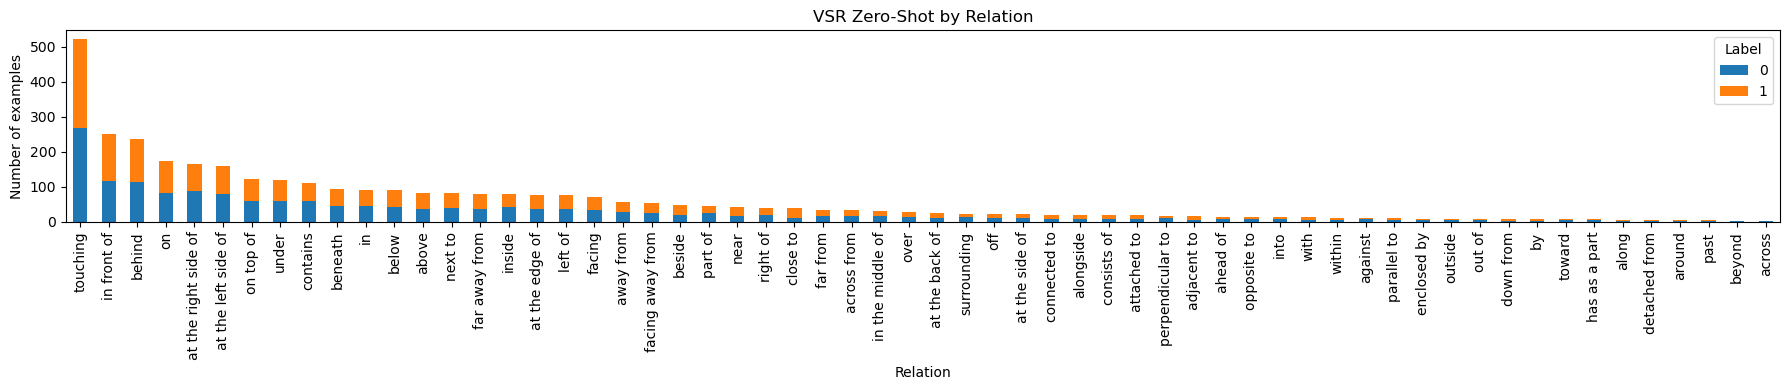

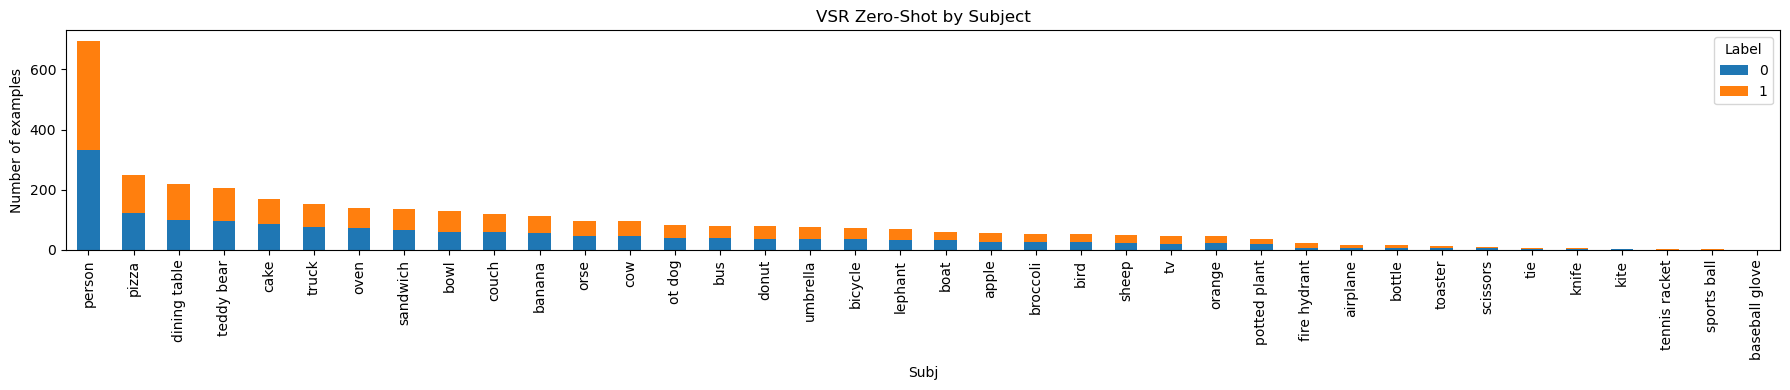

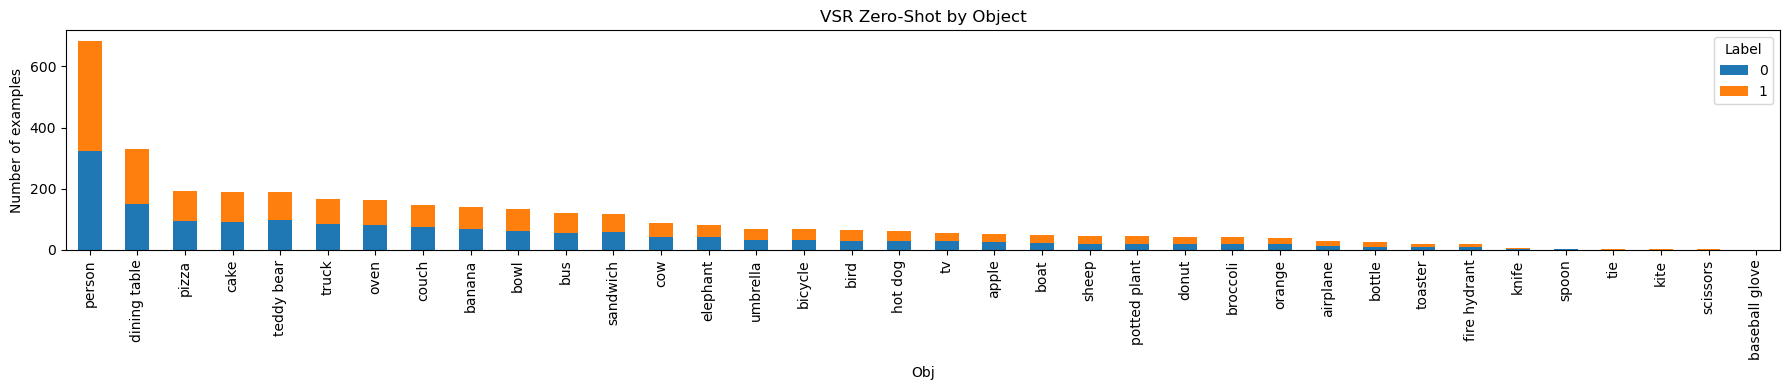

In [4]:
# Initial distribution plots
plot_stacked_bar(df, 'relation', title="VSR Zero-Shot by Relation")
plot_stacked_bar(df, 'subj',     title="VSR Zero-Shot by Subject")
plot_stacked_bar(df, 'obj',      title="VSR Zero-Shot by Object")

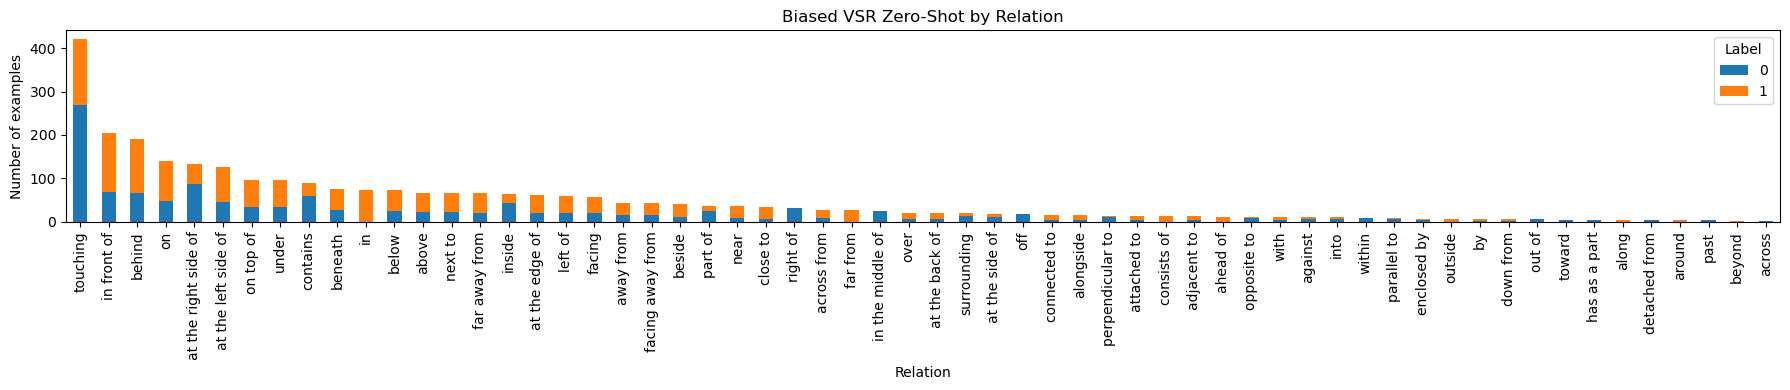

In [7]:
# Under-sample to bias certain relations
df_biased = undersample_by_relation(df, keep_ratio=0.6)
plot_stacked_bar(df_biased, 'relation', title="Biased VSR Zero-Shot by Relation")

In [8]:
# Statistical test of bias
for name, dataset in [("Biased DS", df_biased), ("Original DS", df)]:
    N, k, pval = test_bias_significance(dataset)
    print(f"Accuracy {name} = {k/N:.3%}, p-value vs. 0.5 = {pval:.3g}")

Accuracy Biased DS = 68.990%, p-value vs. 0.5 = 1.38e-92
Accuracy Original DS = 53.224%, p-value vs. 0.5 = 7.43e-05


In [7]:
# Add Vision Bias: dataset loader
disk_loc = os.path.join(os.environ.get("DATA_PATH", "/data"), "vsr")
def create_dataset(disk_loc,
                   bias_prob=0.3,
                   bias_strength=0.1,
                   seed=42,
                   image_size=32,
                   batch_size=64,
                   map_workers=1,
                   loader_workers=0):
    """
    Load the disk dataset, apply subtle color bias, and return PyTorch DataLoaders.
    Parallel map uses `map_workers`, DataLoader workers set by `loader_workers`.
    """
    random.seed(seed)
    torch.manual_seed(seed)
    dataset = load_from_disk(disk_loc)

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size), antialias=True),
        transforms.ToTensor(),
    ])

    def add_pixel_values(ex):
        img = Image.open(ex["image_path"]).convert("RGB")
        px  = transform(img)
        if bias_prob > 0 and random.random() < bias_prob:
            H, W = px.shape[1:]
            mask = torch.zeros((H, W), dtype=torch.bool)
            idx  = torch.randint(0, H*W, (int(H*W*0.5),))
            a    = idx // W
            b    = idx % W
            mask[a, b] = True
            # boost red for label==1, blue for label==0
            channel = 0 if ex['label']==1 else 2
            px[channel][mask] = torch.clamp(px[channel][mask] + bias_strength, 0, 1)
        ex['pixel_values'] = px
        return ex

    for split in dataset.keys():
        # Use map_workers=1 to avoid nested multiprocessing issues
        dataset[split] = dataset[split].map(
            add_pixel_values,
            remove_columns=["image_path"],
            num_proc=map_workers
        )

    dataset.set_format(type="torch",
                       columns=["pixel_values", "label"],
                       output_all_columns=False)

    return (
        DataLoader(dataset['train'],      batch_size=batch_size, num_workers=loader_workers, shuffle=True,  drop_last=True),
        DataLoader(dataset['validation'], batch_size=batch_size, num_workers=loader_workers, shuffle=False, drop_last=False),
        DataLoader(dataset['test'],       batch_size=batch_size, num_workers=loader_workers, shuffle=False, drop_last=False)
    )


In [8]:
# Create loaders with bias
loader_train, loader_val, loader_test = create_dataset(disk_loc, bias_prob=0.3, bias_strength=0.1)

In [9]:
def plot_image_grid(loader, nrows=8, ncols=8, figsize=(10,10)):
    batch = next(iter(loader))
    imgs  = batch['pixel_values']
    fig   = plt.figure(figsize=figsize)
    grid  = ImageGrid(fig, 111, nrows_ncols=(nrows, ncols), axes_pad=0.1)
    for ax, img in zip(grid, imgs):
        ax.imshow(img.permute(1,2,0).numpy())
        ax.axis('off')
    plt.show()

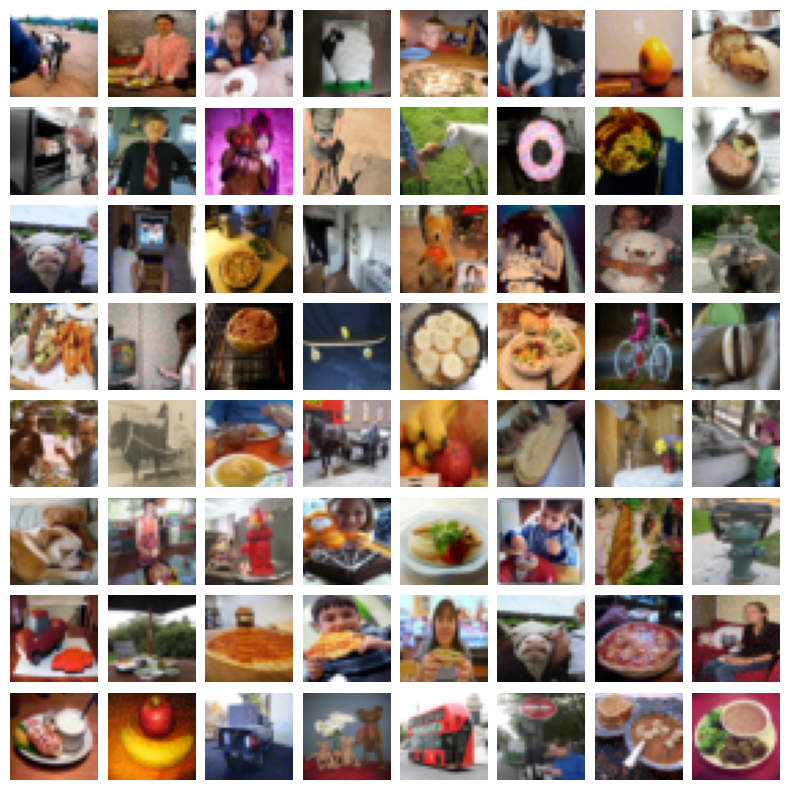

In [10]:
plot_image_grid(loader_train)

In [11]:
# Model definition and utilities
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=1, image_size=32):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, 1, 1)
        self.fc1   = nn.Linear(8*(image_size//2)**2, 64)
        self.fc2   = nn.Linear(64, 32)
        self.fc3   = nn.Linear(32, num_classes)
        self.drop  = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return self.drop(x)


def train_model(model, loader_train, loader_val, optimizer, num_epochs=7, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    train_losses, val_losses, val_accs = [], [], []
    for _ in range(num_epochs):
        model.train()
        total_train = 0
        for batch in tqdm(loader_train, desc='Training'): 
            x, y = batch['pixel_values'].to(device), batch['label'].to(device)
            logits = model(x)
            loss   = nn.BCEWithLogitsLoss()(logits, y.float().unsqueeze(1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train += loss.item()
        train_losses.append(total_train/len(loader_train))

        model.eval()
        total_val, correct, count = 0, 0, 0
        with torch.no_grad():
            for batch in loader_val:
                x, y = batch['pixel_values'].to(device), batch['label'].to(device)
                logits = model(x)
                loss   = nn.BCEWithLogitsLoss()(logits, y.float().unsqueeze(1))
                total_val += loss.item()
                preds = (logits.squeeze()>0).float()
                correct += preds.eq(y.view_as(preds)).sum().item()
                count   += len(preds)
        val_losses.append(total_val/len(loader_val))
        val_accs.append(correct/count)
        print(f"Train: {train_losses[-1]:.3f}, Val: {val_losses[-1]:.3f}, Acc: {val_accs[-1]:.3f}")
    return train_losses, val_losses, val_accs


def evaluate_model(model, loader_test, device=None, B=5000):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device).eval()
    total, correct, count = 0, 0, 0
    preds, y_true = [], []
    with torch.no_grad():
        for batch in loader_test:
            x, y = batch['pixel_values'].to(device), batch['label'].to(device)
            logits = model(x)
            loss   = nn.BCEWithLogitsLoss()(logits, y.float().unsqueeze(1))
            total += loss.item()
            pred  = (logits.squeeze()>0).float()
            correct += pred.eq(y.view_as(pred)).sum().item()
            count   += len(pred)
            preds.extend(pred.cpu().numpy())
            y_true.extend(y.cpu().numpy())
    acc = correct/count
    ci_low, ci_upp = proportion_confint(count=correct, nobs=count, method='wilson')
    binom_p = binomtest(correct, count, p=0.5, alternative='greater').pvalue
    boot = np.array([np.mean(np.random.choice(np.array(preds)==np.array(y_true), count, replace=True)) for _ in range(B)])
    return {
        'loss': round(total / len(loader_test), 3),
        'accuracy': round(acc, 3),
        'wilson_ci': (
            round(ci_low, 3),
            round(ci_upp, 3)
        ),
        'binom_p': round(binom_p, 3),
        'bootstrap_ci': (
            round(np.percentile(boot, 2.5), 3),
            round(np.percentile(boot, 97.5), 3)
        )
    }


In [12]:
# Train and save models for different bias strengths
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
for bs in [0.3, 0.1]:
    print(f"\nBias strength: {bs}")
    loader_train, loader_val, loader_test = create_dataset(disk_loc, bias_prob=0.3, bias_strength=bs)
    model = SimpleCNN().to(device)
    opt   = optim.AdamW(model.parameters())
    train_model(model, loader_train, loader_val, opt, num_epochs=7, device=device)

torch.save(model.state_dict(), f"cnn_biased_30pct_strength_10.pth")

Device: cuda

Bias strength: 0.3


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.685, Val: 0.665, Acc: 0.626


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.675, Val: 0.640, Acc: 0.609


...

Train: 0.692, Val: 0.691, Acc: 0.515


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.693, Val: 0.695, Acc: 0.491


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.691, Val: 0.689, Acc: 0.579


In [13]:
# Evaluate the last trained biased model
metrics_biased = evaluate_model(model, loader_test, device=device)
print(metrics_biased)

{'loss': 0.692, 'accuracy': 0.543, 'wilson_ci': (0.515, 0.57), 'binom_p': np.float64(0.002), 'bootstrap_ci': (np.float64(0.514), np.float64(0.572))}


In [14]:
# Same training and evaluation on original (unbiased) dataset
loader_train, loader_val, loader_test = create_dataset(disk_loc, bias_prob=-1, bias_strength=0)
model = SimpleCNN().to(device)
opt   = optim.AdamW(model.parameters())
train_model(model, loader_train, loader_val, opt, num_epochs=7, device=device)
metrics_orig = evaluate_model(model, loader_test, device=device)
print(metrics_orig)

Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.694, Val: 0.696, Acc: 0.494


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.694, Val: 0.694, Acc: 0.476


Training:   0%|          | 0/54 [00:00<?, ?it/s]

...

Train: 0.691, Val: 0.700, Acc: 0.482


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.692, Val: 0.702, Acc: 0.491


Training:   0%|          | 0/54 [00:00<?, ?it/s]

Train: 0.691, Val: 0.698, Acc: 0.491
{'loss': 0.691, 'accuracy': 0.536, 'wilson_ci': (0.508, 0.564), 'binom_p': np.float64(0.006), 'bootstrap_ci': (np.float64(0.507), np.float64(0.565))}
